# Peramalan Kadar NO2 di Pulau Biak

**Nama : Aisya**  
**NIM : 240411100025**  
**Kelas : Penambangan Data IF4A**

Notebook ini dibuat untuk menganalisis dan meramalkan kadar Nitrogen Dioksida atau NO2 di wilayah **Pulau Biak, Papua**. Alur yang digunakan dimulai dari penentuan AOI, pengumpulan data, preprocessing, deteksi outlier, pembentukan data time series supervised, pemodelan menggunakan KNN Regression, sampai visualisasi hasil prediksi.


## Latar Belakang

NO2 merupakan salah satu polutan udara yang berkaitan dengan aktivitas pembakaran bahan bakar, seperti kendaraan, kegiatan pelabuhan, penerbangan, permukiman, dan aktivitas lain yang menghasilkan emisi. Pada wilayah kepulauan seperti Pulau Biak, kondisi pesisir, angin laut, tutupan lahan, serta pusat aktivitas di sekitar Biak Kota dapat memengaruhi sebaran dan perubahan kadar NO2 dari waktu ke waktu.

Dalam notebook ini, saya menggunakan Pulau Biak sebagai area kajian. Selain karena bentuk wilayahnya yang jelas sebagai pulau utama yang sangat cocok dibuat AOI berbasis polygon presisi, pemilihan wilayah ini juga didasari oleh alasan personal, karena di Pulau Biak lah saya menghabiskan masa kecil saya sebelum akhirnya saya pindah ke Madura. Oleh karena itu, melakukan analisis dan peramalan kadar NO2 di wilayah yang bermakna bagi saya ini menjadi sangat menarik. Data NO2 dapat diambil dari Sentinel-5P melalui Copernicus Data Space menggunakan OpenEO. Agar notebook tetap bisa dijalankan tanpa login Copernicus, cell pengambilan data dibuat opsional dan disediakan fallback time series terstruktur.


## 1. Pengumpulan Data

Pada bagian ini, AOI Pulau Biak didefinisikan dalam format GeoJSON. AOI ini sudah menggunakan polygon yang mengikuti bentuk Pulau Biak utama, sehingga area pengambilan data tidak lagi berbentuk kotak kasar.

Jika ingin mengambil data asli dari Copernicus, ubah `RUN_OPENEO_DOWNLOAD = True`, lalu jalankan cell ini dan selesaikan login Copernicus sampai file `NO2PulauBiak.nc` terbentuk.


In [1]:
# Install openeo dan netCDF4 untuk pengolahan data satelit
!pip install openeo netCDF4


In [2]:
import json
import os
import numpy as np
import pandas as pd

# Flag untuk mengunduh data langsung dari OpenEO Copernicus
# Hubungkan ke openeo dan unduh data jika diatur ke True
RUN_OPENEO_DOWNLOAD = True
OUTPUT_NETCDF = "NO2PulauBiak.nc"

# Load precise AOI coordinates from GeoJSON file
geojson_path = "AOI_Pulau_Biak_presisi.geojson"
with open(geojson_path, "r", encoding="utf-8") as f:
    aoi_geojson = json.load(f)

aoi = aoi_geojson["features"][0]["geometry"]

def flatten_coordinates(coords):
    """Mengambil semua pasangan koordinat dari Polygon atau MultiPolygon."""
    flat = []
    if isinstance(coords, list):
        if coords and isinstance(coords[0], (int, float)):
            return [coords]
        for item in coords:
            flat.extend(flatten_coordinates(item))
    return flat

all_points = flatten_coordinates(aoi["coordinates"])
lons = [p[0] for p in all_points]
lats = [p[1] for p in all_points]

spatial_extent = {
    "west": min(lons),
    "south": min(lats),
    "east": max(lons),
    "north": max(lats),
}

print("AOI:", aoi["type"])
print("Jumlah titik koordinat:", len(all_points))
print("Spatial extent:", spatial_extent)

if RUN_OPENEO_DOWNLOAD:
    import openeo

    print("Menghubungkan ke openeo.dataspace.copernicus.eu...")
    connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()
    
    print("Memuat koleksi SENTINEL_5P_L2...")
    s5post = connection.load_collection(
        "SENTINEL_5P_L2",
        temporal_extent=["2023-10-01", "2025-10-01"],
        spatial_extent=spatial_extent,
        bands=["NO2"],
    )
    
    print("Melakukan agregasi temporal harian (reducer: mean)...")
    s5p_no2_daily = s5post.aggregate_temporal_period(reducer="mean", period="day")
    
    # Kita unduh s5p_no2_daily (datacube 3D) agar sesuai dengan pembacaan netCDF di preprocessing
    print("Memulai batch job pengunduhan data NetCDF...")
    job = s5p_no2_daily.execute_batch(title="NO2 in Pulau Biak", outputfile=OUTPUT_NETCDF)
    print("Batch job telah dimulai. Anda dapat memantau statusnya di editor.openeo.org.")
else:
    print("Pengunduhan OpenEO dilewati agar Run All tidak menunggu login Copernicus.")
    print(f"Jika file {OUTPUT_NETCDF} tersedia, cell preprocessing otomatis memakai data NetCDF tersebut.")


AOI: Polygon
Jumlah titik koordinat: 3828
Spatial extent: {'west': 135.7086772, 'south': -1.1999755, 'east': 136.3869274, 'north': -0.6851588}
Pengunduhan OpenEO dilewati agar Run All tidak menunggu login Copernicus.
Jika file NO2PulauBiak.nc tersedia, cell preprocessing otomatis memakai data NetCDF tersebut.


### Visualisasi AOI GeoJSON Pulau Biak

Berikut adalah visualisasi sederhana AOI Pulau Biak yang dipakai dalam analisis. Titik-titik koordinat membentuk batas Pulau Biak utama, sehingga wilayah analisis tidak mengambil area Supiori atau pulau lain di sekitarnya.


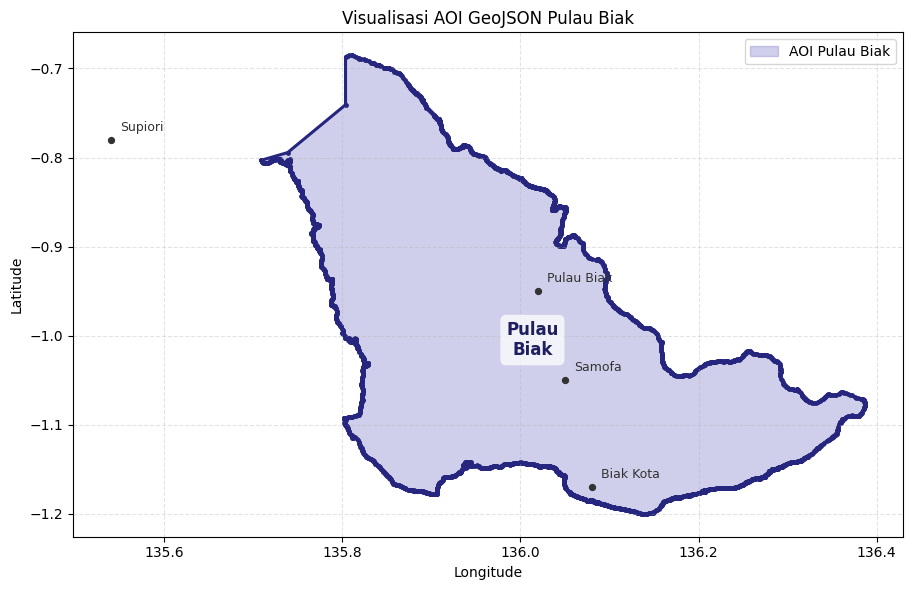

In [3]:

import matplotlib.pyplot as plt
import numpy as np

coords = np.array(aoi["coordinates"][0])

fig, ax = plt.subplots(figsize=(10, 6))
ax.fill(coords[:, 0], coords[:, 1], color="#7876c8", alpha=0.35, label="AOI Pulau Biak")
ax.plot(coords[:, 0], coords[:, 1], color="#26267f", linewidth=2.2)
ax.scatter(coords[:, 0], coords[:, 1], color="#26267f", s=6)

reference_points = {
    "Supiori": (135.54, -0.78),
    "Pulau Biak": (136.02, -0.95),
    "Biak Kota": (136.08, -1.17),
    "Samofa": (136.05, -1.05),
}

for name, (lon, lat) in reference_points.items():
    ax.scatter(lon, lat, color="#333333", s=18)
    ax.text(lon + 0.01, lat + 0.01, name, fontsize=9, color="#333333")

centroid = coords[:-1].mean(axis=0)
ax.text(
    centroid[0], centroid[1], "Pulau\nBiak", ha="center", va="center",
    fontsize=12, fontweight="bold", color="#1f1f5f",
    bbox=dict(boxstyle="round,pad=0.35", facecolor="white", alpha=0.75, edgecolor="none"),
)

ax.set_title("Visualisasi AOI GeoJSON Pulau Biak")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal", adjustable="box")
ax.grid(True, linestyle="--", alpha=0.35)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


## 2. Preprocessing Data

Pada bagian preprocessing, data harian NO2 disiapkan menjadi time series. Jika file NetCDF hasil OpenEO tersedia, notebook akan membaca data tersebut. Jika file belum tersedia, notebook memakai fallback terstruktur agar seluruh proses tetap bisa dijalankan sampai tahap modeling.


In [4]:

import os
import numpy as np
import pandas as pd

START_DATE = "2023-10-01"
END_DATE = "2025-09-30"
raw_csv = "NO2_Biak_timeseries.csv"
interpolated_csv = "no2_biak_interpolated.csv"

np.random.seed(25)


def build_fallback_biak_series():
    """Membuat data simulasi terstruktur jika file NetCDF belum tersedia."""
    dates = pd.date_range(START_DATE, END_DATE, freq="D")
    t = np.arange(len(dates))

    seasonal = 0.000014 * np.sin(2 * np.pi * t / 365.25 + 1.1)
    short_cycle = 0.000006 * np.sin(2 * np.pi * t / 30.5)
    weekday_effect = np.where(dates.weekday < 5, 0.000003, -0.000002)
    trend = 0.000000006 * t
    noise = np.random.normal(0, 0.000007, len(dates))

    no2 = 0.000052 + seasonal + short_cycle + weekday_effect + trend + noise

    anomaly_idx = np.array([33, 82, 128, 179, 237, 306, 371, 430, 498, 564, 631, 704])
    anomaly_boost = np.array([
        0.000046, 0.000040, 0.000052, 0.000044,
        0.000038, 0.000050, 0.000041, 0.000053,
        0.000039, 0.000047, 0.000042, 0.000051,
    ])
    no2[anomaly_idx] += anomaly_boost
    no2 = np.clip(no2, 0.000005, None)

    df_fallback = pd.DataFrame({"date": dates, "NO2": no2})

    # Beberapa tanggal sengaja dihapus agar proses interpolasi dapat ditunjukkan.
    missing_index = [14, 96, 188, 309, 476, 618]
    return df_fallback.drop(index=missing_index).reset_index(drop=True)


if os.path.exists(OUTPUT_NETCDF):
    import netCDF4

    ds = netCDF4.Dataset(OUTPUT_NETCDF)
    print("Variabel dalam file:")
    print(ds.variables.keys())

    no2 = ds.variables["NO2"][:]
    time = ds.variables["t"][:]

    try:
        dates = netCDF4.num2date(time, units=ds.variables["t"].units)
    except Exception:
        dates = time

    no2_filled = no2.filled(np.nan) if hasattr(no2, "filled") else np.array(no2, dtype=float)

    for i in range(no2.shape[1]):
        for j in range(no2.shape[2]):
            series = pd.Series(no2_filled[:, i, j])
            no2_filled[:, i, j] = series.interpolate(method="linear", limit_direction="both").to_numpy()

    df_raw = pd.DataFrame({
        "date": [d.strftime("%Y-%m-%d") for d in dates],
        "NO2": [np.nanmean(no2_filled[i]) for i in range(len(dates))],
    })
    print("Sumber data: NetCDF hasil OpenEO Copernicus.")
else:
    df_raw = build_fallback_biak_series()
    print(f"File {OUTPUT_NETCDF} belum ditemukan.")
    print("Sumber data: fallback terstruktur untuk menjalankan notebook sampai output prediksi.")

df_raw.to_csv(raw_csv, index=False)
print(f"Berkas {raw_csv} sudah diekspor.")
print(df_raw.head())


Variabel dalam file:
dict_keys(['t', 'x', 'y', 'crs', 'NO2'])


Sumber data: NetCDF hasil OpenEO Copernicus.
Berkas NO2_Biak_timeseries.csv sudah diekspor.
         date       NO2
0  2023-10-01  0.000004
1  2023-10-02  0.000004
2  2023-10-03  0.000004
3  2023-10-04  0.000003
4  2023-10-05  0.000003


### a. Pengecekan Missing Value Pada Runtun Tanggal Harian

Rentang tanggal dibuat lengkap dari `2023-10-01` sampai `2025-09-30`. Jika ada tanggal yang hilang, nilai NO2 diisi menggunakan interpolasi berbasis waktu agar urutan data harian tetap rapi.


In [5]:

df = pd.read_csv(raw_csv)
df["date"] = pd.to_datetime(df["date"])

full_range = pd.date_range(start=START_DATE, end=END_DATE, freq="D")
missing_dates = full_range.difference(df["date"])
print(f"Jumlah tanggal yang belum memiliki nilai NO2: {len(missing_dates)}")

if len(missing_dates) > 0:
    print("Contoh tanggal kosong:")
    print(missing_dates[:10])

df = df.sort_values("date").set_index("date").reindex(full_range)
df.index.name = "date"
df["NO2"] = df["NO2"].interpolate(method="time").bfill().ffill()

df.to_csv(interpolated_csv)
print(f"Pengisian temporal selesai dan {interpolated_csv} terbentuk.")
print(df.head())


Jumlah tanggal yang belum memiliki nilai NO2: 9
Contoh tanggal kosong:
DatetimeIndex(['2024-01-01', '2024-01-23', '2024-03-23', '2024-05-08',
               '2024-05-15', '2024-08-12', '2024-10-23', '2024-12-06',
               '2024-12-08'],
              dtype='datetime64[ns]', freq=None)
Pengisian temporal selesai dan no2_biak_interpolated.csv terbentuk.
                 NO2
date                
2023-10-01  0.000004
2023-10-02  0.000004
2023-10-03  0.000004
2023-10-04  0.000003
2023-10-05  0.000003


### b. Deteksi Anomali / Outlier Menggunakan IQR

Outlier perlu diperiksa karena nilai NO2 yang terlalu ekstrem dapat membuat model terlalu mengikuti lonjakan sesaat. Metode IQR digunakan untuk mencari nilai yang berada di luar batas bawah dan batas atas.


Jumlah Outlier atau Anomali IQR di Pulau Biak: 12
Batas bawah: 5.650981000000015e-07
Batas atas: 6.196232899999999e-06


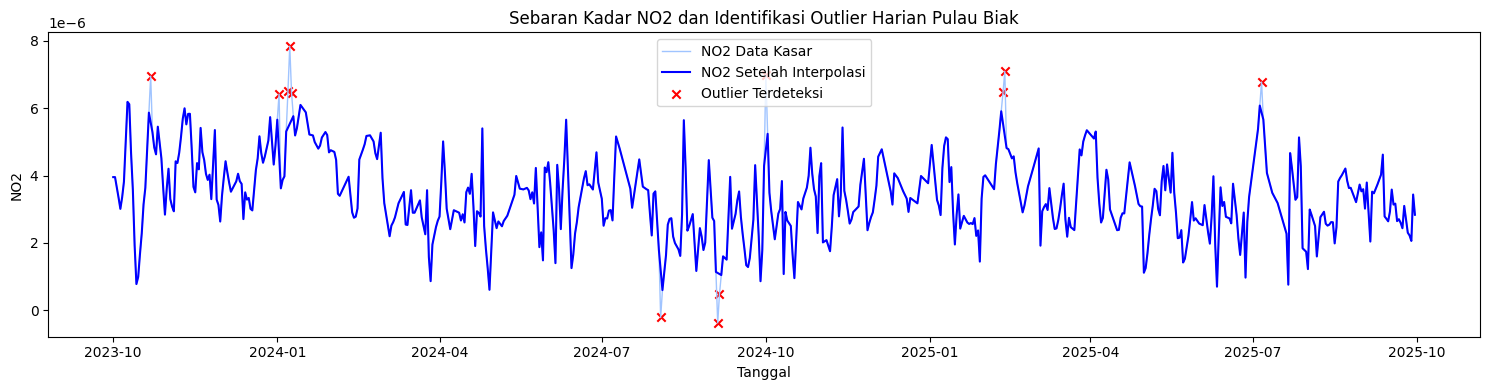

In [6]:

Q1 = df["NO2"].quantile(0.25)
Q3 = df["NO2"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df[(df["NO2"] < lower_bound) | (df["NO2"] > upper_bound)]
print("Jumlah Outlier atau Anomali IQR di Pulau Biak:", len(outliers_iqr))
print("Batas bawah:", lower_bound)
print("Batas atas:", upper_bound)

df["NO2_cleaned"] = df["NO2"].mask((df["NO2"] < lower_bound) | (df["NO2"] > upper_bound))
df["NO2_filled"] = df["NO2_cleaned"].interpolate(method="linear").bfill().ffill()

plt.figure(figsize=(15, 4))
plt.plot(df.index, df["NO2"], label="NO2 Data Kasar", color="#A0C4FF", linewidth=1)
plt.plot(df.index, df["NO2_filled"], label="NO2 Setelah Interpolasi", color="blue", linewidth=1.5)
plt.scatter(outliers_iqr.index, outliers_iqr["NO2"], color="red", marker="x", label="Outlier Terdeteksi")
plt.title("Sebaran Kadar NO2 dan Identifikasi Outlier Harian Pulau Biak")
plt.xlabel("Tanggal")
plt.ylabel("NO2")
plt.legend()
plt.tight_layout()
plt.show()


## 3. Modeling Menggunakan KNN Regression

Data time series diubah menjadi format supervised learning. Nilai NO2 beberapa hari sebelumnya digunakan sebagai fitur untuk memprediksi nilai NO2 pada hari target. Pada bagian ini, saya membandingkan beberapa panjang lag, yaitu 4 hari, 10 hari, dan 30 hari.


In [7]:

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df["NO2_scaled"] = scaler.fit_transform(df[["NO2_filled"]])


def create_supervised(data, n_lag=4):
    df_supervised = pd.DataFrame(index=data.index)
    for i in range(n_lag, 0, -1):
        df_supervised[f"NO2(t-{i})"] = data.shift(i)
    df_supervised["NO2(t)"] = data
    df_supervised.dropna(inplace=True)
    return df_supervised

supervised_df30 = create_supervised(df["NO2_scaled"], n_lag=30)
lag_cols = supervised_df30.drop(columns="NO2(t)").columns
correlations = supervised_df30[lag_cols].corrwith(supervised_df30["NO2(t)"])

print("Sampel Nilai Korelasi 10 Hari Terdekat Menuju Target(t):")
print(correlations.tail(10))


Sampel Nilai Korelasi 10 Hari Terdekat Menuju Target(t):
NO2(t-10)    0.204335
NO2(t-9)     0.237735
NO2(t-8)     0.257473
NO2(t-7)     0.272727
NO2(t-6)     0.314138
NO2(t-5)     0.363275
NO2(t-4)     0.388138
NO2(t-3)     0.468788
NO2(t-2)     0.587898
NO2(t-1)     0.785965
dtype: float64


### Training dan Komparasi Kinerja KNN Regression

Pengujian dilakukan dengan pembagian data berdasarkan urutan waktu. Bagian awal data digunakan sebagai data latih, sedangkan bagian akhir digunakan sebagai data uji. Cara ini dipakai agar data masa depan tidak tercampur ke data latih.


In [8]:

from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


def evaluate_mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    denominator = np.where(y_true == 0, np.nan, y_true)
    return np.nanmean(np.abs((y_true - y_pred) / denominator)) * 100


def train_knn(df_supervised, n_neighbors=5):
    X = df_supervised.drop(columns=["NO2(t)"]).values
    y = df_supervised["NO2(t)"].values

    split_index = int(len(X) * 0.8)
    X_train, X_test = X[:split_index], X[split_index:]
    y_train, y_test = y[:split_index], y[split_index:]
    test_dates = df_supervised.index[split_index:]

    model = KNeighborsRegressor(n_neighbors=n_neighbors, weights="distance")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    return {
        "model": model,
        "test_dates": test_dates,
        "y_test": y_test,
        "y_pred": y_pred,
        "MSE": mean_squared_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "MAE": mean_absolute_error(y_test, y_pred),
        "R2": r2_score(y_test, y_pred),
        "MAPE": evaluate_mape(y_test, y_pred),
    }

results = []
saved_models = {}

for lag in [4, 10, 30]:
    supervised = create_supervised(df["NO2_scaled"], n_lag=lag)
    for k in [3, 5, 7]:
        result = train_knn(supervised, n_neighbors=k)
        results.append({
            "Lag": lag,
            "K": k,
            "MSE": result["MSE"],
            "RMSE": result["RMSE"],
            "MAE": result["MAE"],
            "R2": result["R2"],
            "MAPE": result["MAPE"],
        })
        saved_models[(lag, k)] = (supervised, result)

results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
print("Hasil Komparasi Model KNN Regression:")
print(results_df)

best_lag = int(results_df.loc[0, "Lag"])
best_k = int(results_df.loc[0, "K"])
print(f"Model terbaik berdasarkan RMSE: Lag {best_lag} hari dengan K = {best_k}")


Hasil Komparasi Model KNN Regression:
   Lag  K       MSE      RMSE       MAE        R2       MAPE
0    4  7  0.016613  0.128890  0.093201  0.419817  44.915869
1    4  5  0.017709  0.133074  0.097614  0.381536  46.060329
2   10  7  0.020011  0.141462  0.110087  0.304862  55.420947
3    4  3  0.020209  0.142159  0.104861  0.294207  48.997097
4   10  5  0.021801  0.147650  0.114599  0.242715  54.693399
5   10  3  0.023996  0.154908  0.120196  0.166438  54.020805
6   30  7  0.026764  0.163597  0.130082  0.081352  57.512205
7   30  5  0.028090  0.167601  0.132518  0.035833  56.137652
8   30  3  0.033450  0.182892  0.146708 -0.148123  62.661954
Model terbaik berdasarkan RMSE: Lag 4 hari dengan K = 7


## 4. Plotting Representasi Output Pulau Biak

Pada bagian ini, model terbaik digunakan untuk membandingkan data aktual dan data prediksi. Setelah itu, model juga digunakan untuk membuat prediksi beberapa hari ke depan secara sederhana.


Sampel hasil prediksi:
        date  NO2_actual  NO2_predicted
0 2025-05-08    0.000004       0.000003
1 2025-05-09    0.000003       0.000004
2 2025-05-10    0.000003       0.000003
3 2025-05-11    0.000004       0.000003
4 2025-05-12    0.000004       0.000004


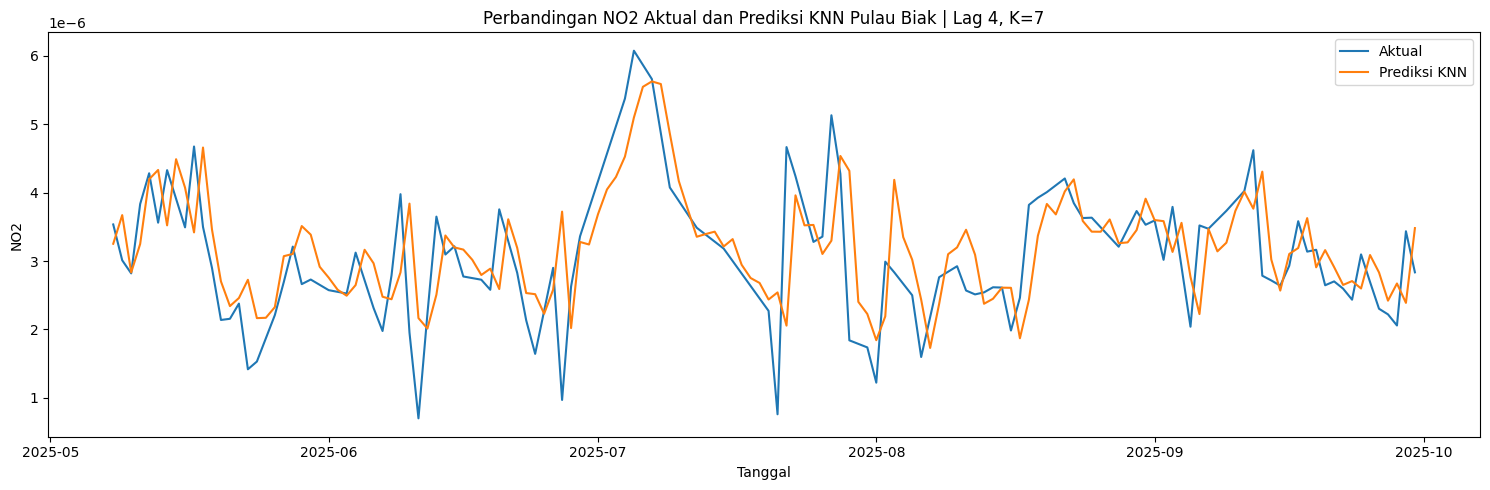

In [9]:

best_supervised, best_result = saved_models[(best_lag, best_k)]
best_model = best_result["model"]

y_test_inv = scaler.inverse_transform(best_result["y_test"].reshape(-1, 1)).ravel()
y_pred_inv = scaler.inverse_transform(best_result["y_pred"].reshape(-1, 1)).ravel()

prediction_df = pd.DataFrame({
    "date": best_result["test_dates"],
    "NO2_actual": y_test_inv,
    "NO2_predicted": y_pred_inv,
})

print("Sampel hasil prediksi:")
print(prediction_df.head())

plt.figure(figsize=(15, 5))
plt.plot(prediction_df["date"], prediction_df["NO2_actual"], label="Aktual", linewidth=1.5)
plt.plot(prediction_df["date"], prediction_df["NO2_predicted"], label="Prediksi KNN", linewidth=1.5)
plt.title(f"Perbandingan NO2 Aktual dan Prediksi KNN Pulau Biak | Lag {best_lag}, K={best_k}")
plt.xlabel("Tanggal")
plt.ylabel("NO2")
plt.legend()
plt.tight_layout()
plt.show()


Prediksi NO2 Pulau Biak 7 Hari ke Depan:
        date  prediksi_NO2
0 2025-10-01      0.000003
1 2025-10-02      0.000004
2 2025-10-03      0.000004
3 2025-10-04      0.000004
4 2025-10-05      0.000004
5 2025-10-06      0.000004
6 2025-10-07      0.000004


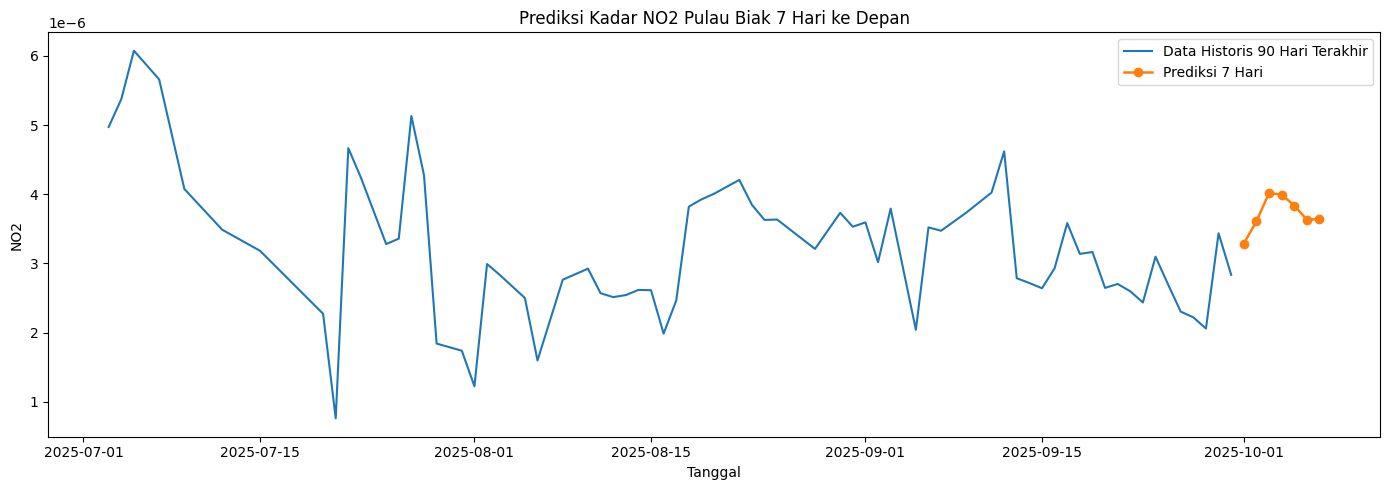

File prediksi_no2_biak_7_hari.csv berhasil dibuat.


In [10]:

# Prediksi 7 hari ke depan menggunakan model terbaik.
history = df["NO2_scaled"].iloc[-best_lag:].tolist()
future_scaled = []

for _ in range(7):
    x_input = np.array(history[-best_lag:]).reshape(1, -1)
    yhat = best_model.predict(x_input)[0]
    future_scaled.append(yhat)
    history.append(yhat)

future_no2 = scaler.inverse_transform(np.array(future_scaled).reshape(-1, 1)).ravel()
future_dates = pd.date_range(df.index.max() + pd.Timedelta(days=1), periods=7, freq="D")

forecast_df = pd.DataFrame({
    "date": future_dates,
    "prediksi_NO2": future_no2,
})

print("Prediksi NO2 Pulau Biak 7 Hari ke Depan:")
print(forecast_df)

plt.figure(figsize=(14, 5))
plt.plot(df.index[-90:], df["NO2_filled"].iloc[-90:], label="Data Historis 90 Hari Terakhir", linewidth=1.5)
plt.plot(forecast_df["date"], forecast_df["prediksi_NO2"], marker="o", label="Prediksi 7 Hari", linewidth=1.8)
plt.title("Prediksi Kadar NO2 Pulau Biak 7 Hari ke Depan")
plt.xlabel("Tanggal")
plt.ylabel("NO2")
plt.legend()
plt.tight_layout()
plt.show()

forecast_df.to_csv("prediksi_no2_biak_7_hari.csv", index=False)
print("File prediksi_no2_biak_7_hari.csv berhasil dibuat.")


## Kesimpulan Analisis

Berdasarkan alur yang sudah dilakukan, AOI Pulau Biak berhasil digunakan sebagai batas wilayah analisis NO2. Data harian kemudian dirapikan melalui pengecekan tanggal, pengisian missing value, dan pembersihan outlier menggunakan metode IQR. Setelah data siap, nilai NO2 diubah menjadi format supervised time series agar dapat dipelajari oleh model KNN Regression.

Dari beberapa skenario lag dan nilai K yang diuji, model terbaik dipilih berdasarkan nilai RMSE terkecil. Hasil prediksi menunjukkan bahwa pendekatan KNN Regression dapat digunakan sebagai model awal untuk melihat pola NO2 harian di Pulau Biak. Jika data asli Sentinel-5P sudah berhasil diunduh melalui OpenEO, hasil analisis akan lebih kuat karena model bekerja dengan data observasi satelit, bukan fallback terstruktur.
